In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

os.makedirs('/content/gambar_mentah', exist_ok=True)

print("Mengekstrak gambar, tunggu sebentar...")
!unzip -q -j '/content/drive/MyDrive/RM/Dataset/HAM10000_Full.zip' -d /content/gambar_mentah/

total_gambar = len(os.listdir('/content/gambar_mentah'))
print(f"EKSTRAKSI SELESAI! Ada {total_gambar} gambar di dalam folder.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mengekstrak gambar, tunggu sebentar...
EKSTRAKSI SELESAI! Ada 20032 gambar di dalam folder.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving HAM10000_metadata.csv to HAM10000_metadata.csv


In [ ]:
import os
import pandas as pd
import shutil
from tqdm import tqdm

# Pastikan file CSV sudah ada di Colab
CSV_PATH = '/content/HAM10000_metadata.csv'
FOLDER_MENTAH = '/content/gambar_mentah'
FOLDER_TUJUAN = '/content/dataset_asli'

MEL_DIR = os.path.join(FOLDER_TUJUAN, 'melanoma')
NON_MEL_DIR = os.path.join(FOLDER_TUJUAN, 'non_melanoma')

os.makedirs(MEL_DIR, exist_ok=True)
os.makedirs(NON_MEL_DIR, exist_ok=True)
print("Folder tujuan berhasil dibuat.")

print("Membaca file CSV dan memulai sortir gambar...")

try:
    df = pd.read_csv(CSV_PATH)
except FileNotFoundError:
    print(f"ERROR: File '{CSV_PATH}' tidak ditemukan! Jangan lupa upload dulu file CSV-nya ya.")
    df = None

if df is not None:
    count_mel = 0
    count_non = 0

    for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Menyortir Data"):
        nama_gambar = str(row['image_id']) + '.jpg'
        path_sumber = os.path.join(FOLDER_MENTAH, nama_gambar)

        kelas_penyakit = str(row['dx']).strip().lower()

        if os.path.exists(path_sumber):
            if kelas_penyakit == 'mel':
                path_tujuan = os.path.join(MEL_DIR, nama_gambar)
                count_mel += 1
            else:
                path_tujuan = os.path.join(NON_MEL_DIR, nama_gambar)
                count_non += 1

            shutil.move(path_sumber, path_tujuan)

    print("\nPROSES SORTIR SELESAI!")
    print(f"Jumlah Melanoma     : {count_mel} gambar")
    print(f"Jumlah Non-Melanoma : {count_non} gambar")

    if len(os.listdir(FOLDER_MENTAH)) == 0:
        os.rmdir(FOLDER_MENTAH)

Folder tujuan berhasil dibuat.
Membaca file CSV dan memulai sortir gambar...


Menyortir Data: 100%|██████████| 10015/10015 [00:01<00:00, 8305.55it/s]


PROSES SORTIR SELESAI!
Jumlah Melanoma     : 1113 gambar
Jumlah Non-Melanoma : 8902 gambar


# Pre-Processing

In [ ]:
import cv2
import os
import glob
import numpy as np
from tqdm import tqdm

input_base_folder = '/content/dataset_asli'
output_base_folder = '/content/dataset_bersih_224'

daftar_kelas = ['melanoma', 'non_melanoma']

for kelas in daftar_kelas:
    input_folder = os.path.join(input_base_folder, kelas)
    output_folder = os.path.join(output_base_folder, kelas)

    os.makedirs(output_folder, exist_ok=True)

    image_paths = glob.glob(os.path.join(input_folder, '*.jpg'))

    if len(image_paths) == 0:
        print(f"\nTidak ada gambar di {input_folder}. Melewati kelas {kelas}...")
        continue

    print(f"\nMemulai proses untuk kelas: [{kelas.upper()}] - {len(image_paths)} gambar")

    for img_path in tqdm(image_paths, desc=f"Memproses {kelas}"):
        file_name = os.path.basename(img_path)

        img_bgr = cv2.imread(img_path)

        if img_bgr is None:
            print(f"\nFile corrupt dilewati: {file_name}")
            continue

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (11, 11))
        blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
        _, mask = cv2.threshold(blackhat, 7, 255, cv2.THRESH_BINARY)

        inpainted = cv2.inpaint(img_rgb, mask, inpaintRadius=2, flags=cv2.INPAINT_TELEA)

        final_img = cv2.resize(inpainted, (224, 224))

        final_img_bgr = cv2.cvtColor(final_img, cv2.COLOR_RGB2BGR)

        save_path = os.path.join(output_folder, file_name)
        cv2.imwrite(save_path, final_img_bgr)

print("\nEKSEKUSI SELESAI! Seluruh citra telah dibersihkan, di-resize, dan dipisahkan sesuai kelasnya di folder tujuan.")


Memulai proses untuk kelas: [MELANOMA] - 1113 gambar


Memproses melanoma: 100%|██████████| 1113/1113 [01:55<00:00,  9.63it/s]



Memulai proses untuk kelas: [NON_MELANOMA] - 8902 gambar


Memproses non_melanoma: 100%|██████████| 8902/8902 [12:56<00:00, 11.46it/s]


EKSEKUSI SELESAI! Seluruh citra telah dibersihkan, di-resize, dan dipisahkan sesuai kelasnya di folder tujuan.


# Data Splitting and Augmentation

In [ ]:
import os
import cv2
import shutil
import random
from sklearn.model_selection import train_test_split
from tqdm import tqdm

if os.path.exists(PATH_OUTPUT):
    shutil.rmtree(PATH_OUTPUT)
    print("🧹 Folder lama dibersihkan.")

PATH_ASLI = '/content/dataset_bersih_224'
PATH_MEL = os.path.join(PATH_ASLI, 'melanoma')
PATH_NON_MEL = os.path.join(PATH_ASLI, 'non_melanoma')

PATH_OUTPUT = '/content/dataset_siap_ekstraksi'
for split in ['train', 'val', 'test']:
    for kelas in ['melanoma', 'non_melanoma']:
        os.makedirs(f'{PATH_OUTPUT}/{split}/{kelas}', exist_ok=True)

print("Memulai proses Data Splitting...")
mel_files     = sorted([f for f in os.listdir(PATH_MEL) if f.endswith(('.jpg','.png'))])
non_mel_files = sorted([f for f in os.listdir(PATH_NON_MEL) if f.endswith(('.jpg','.png'))])

mel_train_val, mel_test = train_test_split(mel_files, test_size=0.2, random_state=42)
mel_train, mel_val = train_test_split(mel_train_val, test_size=0.125, random_state=42)

non_train_val, non_test = train_test_split(non_mel_files, test_size=0.2, random_state=42)
non_train, non_val = train_test_split(non_train_val, test_size=0.125, random_state=42)

def copy_files(file_list, source_dir, dest_dir):
    for f in file_list:
        shutil.copy(os.path.join(source_dir, f), os.path.join(dest_dir, f))

copy_files(mel_train, PATH_MEL, f'{PATH_OUTPUT}/train/melanoma')
copy_files(mel_val, PATH_MEL, f'{PATH_OUTPUT}/val/melanoma')
copy_files(mel_test, PATH_MEL, f'{PATH_OUTPUT}/test/melanoma')

copy_files(non_train, PATH_NON_MEL, f'{PATH_OUTPUT}/train/non_melanoma')
copy_files(non_val, PATH_NON_MEL, f'{PATH_OUTPUT}/val/non_melanoma')
copy_files(non_test, PATH_NON_MEL, f'{PATH_OUTPUT}/test/non_melanoma')

print("\n--- DISTRIBUSI SEBELUM AUGMENTASI ---")
print(f"Data Latih (Train) -> Melanoma: {len(mel_train)} | Non-Melanoma: {len(non_train)}")

print("\nMemulai Augmentasi Gambar (Meningkatkan Spatial Invariance)...")
random.seed(42)

train_mel_dir = f'{PATH_OUTPUT}/train/melanoma'
jumlah_saat_ini = len(mel_train)

faktor_augmentasi = 1
total_augmentasi_baru = jumlah_saat_ini * faktor_augmentasi

def augment_image(image_path, save_dir, prefix):
    img = cv2.imread(image_path)
    if img is None: return

    teknik = random.choice(['flip_h', 'flip_v', 'rotate_90', 'rotate_180', 'zoom'])
    if teknik == 'flip_h': aug_img = cv2.flip(img, 1)
    elif teknik == 'flip_v': aug_img = cv2.flip(img, 0)
    elif teknik == 'rotate_90': aug_img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    elif teknik == 'rotate_180': aug_img = cv2.rotate(img, cv2.ROTATE_180)
    elif teknik == 'zoom':
        h, w = img.shape[:2]
        crop_h, crop_w = int(h * 0.8), int(w * 0.8)
        y1, x1 = (h - crop_h) // 2, (w - crop_w) // 2
        cropped = img[y1:y1+crop_h, x1:x1+crop_w]
        aug_img = cv2.resize(cropped, (w, h), interpolation=cv2.INTER_LINEAR)

    new_filename = f"aug_{prefix}_{teknik}_{os.path.basename(image_path)}"
    cv2.imwrite(os.path.join(save_dir, new_filename), aug_img)

for iterasi in tqdm(range(total_augmentasi_baru), desc="Proses Augmentasi 1x Salinan"):
    file_acak = mel_train[iterasi % jumlah_saat_ini]
    path_file_acak = os.path.join(train_mel_dir, file_acak)
    augment_image(path_file_acak, train_mel_dir, iterasi)

print("\n--- DISTRIBUSI SESUDAH AUGMENTASI ---")
print(f"Data Latih (Train) -> Melanoma: {len(os.listdir(train_mel_dir))} | Non-Melanoma: {len(non_train)}")
print("DATA SPLIT & AUGMENTASI SELESAI! Siap untuk Ekstraksi Fitur.")

Memulai proses Data Splitting...

--- DISTRIBUSI SEBELUM AUGMENTASI ---
Data Latih (Train) -> Melanoma: 778 | Non-Melanoma: 6230

Memulai Augmentasi Gambar (Meningkatkan Spatial Invariance)...


Proses Augmentasi 1x Salinan: 100%|██████████| 778/778 [00:00<00:00, 991.43it/s]


--- DISTRIBUSI SESUDAH AUGMENTASI ---
Data Latih (Train) -> Melanoma: 1556 | Non-Melanoma: 6230
DATA SPLIT & AUGMENTASI SELESAI! Siap untuk Ekstraksi Fitur.


# Ekstraksi 35 Fitur (Otsu + HSV + GLCM)

In [ ]:
import os
import cv2
import numpy as np
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import skew, kurtosis
from tqdm import tqdm
import pandas as pd

BASE_PATH = '/content/dataset_siap_ekstraksi'
SPLITS = ['train', 'val', 'test']
CLASSES = ['melanoma', 'non_melanoma']

def extract_35_features_otsu(img_path):
    img = cv2.imread(img_path)
    if img is None: return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    if np.sum(mask == 255) < 1000:
        mask = np.ones(gray.shape, dtype=np.uint8) * 255

    features = []

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    for i in range(3):
        channel_pixels = hsv[:, :, i][mask == 255]

        if len(channel_pixels) == 0:
            features.extend([0]*5)
            continue

        mean = np.mean(channel_pixels)
        std = np.std(channel_pixels)

        sk = skew(channel_pixels)
        if np.isnan(sk): sk = 0

        kur = kurtosis(channel_pixels)
        if np.isnan(kur): kur = 0

        ran = np.max(channel_pixels) - np.min(channel_pixels)

        features.extend([mean, std, sk, kur, ran])

    gray_quantized = np.clip((gray // 16) + 1, 1, 16).astype(np.uint8)

    gray_quantized[mask == 0] = 0

    glcm_full = graycomatrix(
        gray_quantized,
        distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=17, symmetric=True, normed=False
    )

    glcm_lesion = glcm_full[1:, 1:, :, :]

    glcm_sums = np.sum(glcm_lesion, axis=(0, 1), keepdims=True)
    glcm_sums[glcm_sums == 0] = 1
    glcm_normalized = glcm_lesion / glcm_sums

    features.extend(list(graycoprops(glcm_normalized, 'contrast')[0]))
    features.extend(list(graycoprops(glcm_normalized, 'energy')[0]))
    features.extend(list(graycoprops(glcm_normalized, 'correlation')[0]))
    features.extend(list(graycoprops(glcm_normalized, 'homogeneity')[0]))

    for a in range(4):
        glcm_prob = glcm_normalized[:, :, 0, a]
        ent = max(0.0, -np.sum(glcm_prob * np.log2(glcm_prob + 1e-10)))
        features.append(ent)

    return features

data_tabular = []
gambar_gagal = 0

for split in SPLITS:
    print(f"\nEkstraksi Set: {split.upper()}")
    for label in CLASSES:
        folder = os.path.join(BASE_PATH, split, label)

        valid_extensions = ('.jpg', '.jpeg', '.png')
        files = sorted([f for f in os.listdir(folder) if f.lower().endswith(valid_extensions)])

        print(f"   └── {label}: {len(files)} gambar")

        for f in tqdm(files):
            path = os.path.join(folder, f)
            feat = extract_35_features_otsu(path)

            if feat is not None and not any(np.isnan(val) or np.isinf(val) for val in feat):
                data_tabular.append(feat + [label, split])
            else:
                gambar_gagal += 1

kolom = [f'hsv_{i}' for i in range(15)] + [f'glcm_{i}' for i in range(20)] + ['label', 'split']
df = pd.DataFrame(data_tabular, columns=kolom)

folder_drive = '/content/drive/MyDrive/ML/GitHub/Dataset/'

os.makedirs(folder_drive, exist_ok=True)

csv_path = os.path.join(folder_drive, 'extracted_features_35_Tuned.csv')

df.to_csv(csv_path, index=False)

print(f"\nEKSTRAKSI SELESAI!")
print(f"File CSV berhasil diamankan di: {csv_path}")

total_diproses = len(data_tabular) + gambar_gagal
rasio_gagal = (gambar_gagal / total_diproses) * 100 if total_diproses > 0 else 0

print(f"\nLaporan Quality Control (QC):")
print(f"   Jumlah gambar sukses diekstrak : {len(data_tabular)}")
print(f"   Jumlah gambar dibuang          : {gambar_gagal} ({rasio_gagal:.2f}%)")

if rasio_gagal > 2.0:
    print("PERHATIAN: Rasio pembuangan data di atas 2%. Kemungkinan fitur GLCM Correlation menghasilkan NaN akibat augmentasi rotasi pada area yang terlalu homogen (Variance = 0).")


Ekstraksi Set: TRAIN
   └── melanoma: 1556 gambar


100%|██████████| 1556/1556 [00:14<00:00, 107.28it/s]


   └── non_melanoma: 6230 gambar


100%|██████████| 6230/6230 [00:55<00:00, 111.78it/s]



Ekstraksi Set: VAL
   └── melanoma: 112 gambar


...


Ekstraksi Set: TEST
   └── melanoma: 223 gambar


100%|██████████| 223/223 [00:02<00:00, 106.59it/s]


   └── non_melanoma: 1781 gambar


100%|██████████| 1781/1781 [00:15<00:00, 116.96it/s]



EKSTRAKSI SELESAI!
File CSV berhasil diamankan di: /content/drive/MyDrive/ML/GitHub/Dataset/extracted_features_35_Tuned.csv

Laporan Quality Control (QC):
   Jumlah gambar sukses diekstrak : 10793
   Jumlah gambar dibuang          : 0 (0.00%)


# Training and Evaluasi

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier
import joblib
import os
import warnings

warnings.filterwarnings('ignore')

print("1. Memuat Dataset 35 Fitur (Otsu + HSV + GLCM)...")

csv_path = '/content/drive/MyDrive/RM/Threshold_x_WeightClass/Dataset_Tabular/extracted_features_35_Tuned.csv'
df = pd.read_csv(csv_path)

df['label_encoded'] = np.where(df['label'] == 'melanoma', 1, 0)

train_df = df[df['split'] == 'train']
test_df = df[df['split'] == 'test']

fitur_cols = [c for c in df.columns if c not in ['label', 'split', 'label_encoded']]

X_train, y_train = train_df[fitur_cols].values, train_df['label_encoded'].values
X_test, y_test = test_df[fitur_cols].values, test_df['label_encoded'].values

print(f"Distribusi Latih : Kanker={sum(y_train==1)} | Sehat={sum(y_train==0)}")
print(f"Distribusi Uji   : Kanker={sum(y_test==1)} | Sehat={sum(y_test==0)}")


scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


rasio_xgb = float(sum(y_train == 0)) / sum(y_train == 1)
print(f"\nRasio scale_pos_weight dinamis untuk XGBoost: {rasio_xgb:.2f}")

models = {
    'XGBoost': XGBClassifier(
        n_estimators=1000,
        max_depth=7,
        learning_rate=0.01,
        eval_metric='logloss',
        scale_pos_weight=rasio_xgb,
        random_state=42
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42
    ),
    'SVM': SVC(
        C=100,
        gamma=0.01,
        kernel='rbf',
        probability=True,
        class_weight='balanced',
        random_state=42
    )
}

print("\n2. Melatih Ketiga Algoritma dengan Penalti (Class Weighting)...")
for name, model in models.items():
    print(f"Sedang melatih {name}...")
    model.fit(X_train_scaled, y_train)
print("Training selesai.")


print("\n================= DIAGNOSIS RAW TRAIN SET (DEFAULT THRESHOLD 0.50) =================")
print("Tujuan: Melihat seberapa baik model belajar sebelum di-tuning.\n")

for name, model in models.items():
    y_train_pred = model.predict(X_train_scaled)

    acc = accuracy_score(y_train, y_train_pred)
    rec = recall_score(y_train, y_train_pred)
    prec = precision_score(y_train, y_train_pred, zero_division=0)
    f1 = f1_score(y_train, y_train_pred, zero_division=0)

    cm = confusion_matrix(y_train, y_train_pred)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    print(f"   HASIL TRAIN {name.upper()}")
    print(f"   Akurasi     : {acc*100:.2f}%")
    print(f"   Specificity : {spec*100:.2f}%")
    print(f"   F1-Score    : {f1*100:.2f}%")
    print(f"   Recall      : {rec*100:.2f}%")
    print(f"   Precision   : {prec*100:.2f}%")
    print("   " + "-"*40)

1. Memuat Dataset 35 Fitur (Otsu + HSV + GLCM)...
Distribusi Latih : Kanker=1556 | Sehat=6230
Distribusi Uji   : Kanker=223 | Sehat=1781

Rasio scale_pos_weight dinamis untuk XGBoost: 4.00

2. Melatih Ketiga Algoritma dengan Penalti (Class Weighting)...
Sedang melatih XGBoost...
Sedang melatih Extra Trees...
Sedang melatih SVM...
Training selesai.

================= DIAGNOSIS RAW TRAIN SET (DEFAULT THRESHOLD 0.50) =================
Tujuan: Melihat seberapa baik model belajar sebelum di-tuning.

   HASIL TRAIN XGBOOST
   Akurasi     : 94.10%
   Specificity : 92.63%
   F1-Score    : 87.15%
   Recall      : 100.00%
   Precision   : 77.22%
   ----------------------------------------
   HASIL TRAIN EXTRA TREES
   Akurasi     : 99.58%
   Specificity : 99.47%
   F1-Score    : 98.95%
   Recall      : 100.00%
   Precision   : 97.92%
   ----------------------------------------
   HASIL TRAIN SVM
   Akurasi     : 83.74%
   Specificity : 81.01%
   F1-Score    : 69.94%
   Recall      : 94.67%
   Pr

In [8]:
print("1. Menyiapkan Data Validation Set untuk Tuning...")

val_df = df[df['split'] == 'val']
X_val = val_df[fitur_cols].values
y_val = val_df['label_encoded'].values

X_val_scaled = scaler.transform(X_val)

print(f" Distribusi Validasi : Kanker={sum(y_val==1)} | Sehat={sum(y_val==0)}\n")

thresholds = np.linspace(0.25, 0.5, num=6)

path_simpan_gambar = '/content/drive/MyDrive/ComVis/GitHub/Dynamic_TH/Hasil_Evaluasi/'
os.makedirs(path_simpan_gambar, exist_ok=True)

print("============ MEMULAI OPTIMASI THRESHOLD ============\n")

for name, model in models.items():
    print(f"==================================================")
    print(f" ANALISIS THRESHOLD: {name.upper()}")
    print(f"==================================================")

    prob_val = model.predict_proba(X_val_scaled)[:, 1]

    history_recall, history_precision, history_f1, history_acc, history_spec = [], [], [], [], []

    print(f"{'Threshold':<10} | {'Akurasi':<10} | {'Specificity':<12} | {'F1-Score':<10} | {'Recall':<10} | {'Precision':<10}")
    print("-" * 75)

    for thresh in thresholds:
        y_val_pred = np.where(prob_val >= thresh, 1, 0)

        acc = accuracy_score(y_val, y_val_pred)
        rec = recall_score(y_val, y_val_pred)
        prec = precision_score(y_val, y_val_pred, zero_division=0)
        f1 = f1_score(y_val, y_val_pred, zero_division=0)

        cm = confusion_matrix(y_val, y_val_pred)
        tn, fp, fn, tp = cm.ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0

        history_recall.append(rec)
        history_precision.append(prec)
        history_f1.append(f1)
        history_acc.append(acc)
        history_spec.append(spec)

        print(f"{thresh:<10.2f} | {acc*100:<9.2f}% | {spec*100:<11.2f}% | {f1*100:<9.2f}% | {rec*100:<9.2f}% | {prec*100:<9.2f}%")
    print("\n")


    plt.figure(figsize=(10, 6))

    plt.plot(thresholds, history_acc, label='Accuracy', color='#9B59B6', marker='D', linewidth=2.5)
    plt.plot(thresholds, history_spec, label='Specificity', color='#2ECC71', marker='*', linewidth=2.5)
    plt.plot(thresholds, history_f1, label='F1-Score (Balance)', color='#F1C40F', marker='^', linewidth=2.5)
    plt.plot(thresholds, history_recall, label='Recall (Sensitivity)', color='#E74C3C', marker='o', linewidth=2.5)
    plt.plot(thresholds, history_precision, label='Precision', color='#3498DB', marker='s', linewidth=2.5)

    plt.title(f'Threshold Optimization Curve - {name}\n(Validation Set)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Decision Threshold', fontsize=12, fontweight='bold')
    plt.ylabel('Score (0.0 - 1.0)', fontsize=12, fontweight='bold')
    plt.xticks(thresholds)
    plt.ylim([0.0, 1.05])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=11)

    nama_file = f'Threshold_Tuning_{name.replace(" ", "_")}.png'
    path_gambar = os.path.join(path_simpan_gambar, nama_file)
    plt.savefig(path_gambar, dpi=300, bbox_inches='tight')
    plt.close()

print(f"OPTIMASI SELESAI! Grafik Threshold Tuning (termasuk 5 metrik) berhasil disimpan di folder Drive.")

1. Menyiapkan Data Validation Set untuk Tuning...
 Distribusi Validasi : Kanker=112 | Sehat=891

============ MEMULAI OPTIMASI THRESHOLD ============

 ANALISIS THRESHOLD: XGBOOST
Threshold  | Akurasi    | Specificity  | F1-Score   | Recall     | Precision 
---------------------------------------------------------------------------
0.25       | 71.59    % | 70.15      % | 39.49    % | 83.04    % | 25.91    %
0.30       | 74.68    % | 73.96      % | 41.47    % | 80.36    % | 27.95    %
0.35       | 77.47    % | 77.78      % | 42.64    % | 75.00    % | 29.79    %
0.40       | 80.86    % | 81.82      % | 46.07    % | 73.21    % | 33.61    %
0.45       | 83.05    % | 84.96      % | 47.20    % | 67.86    % | 36.19    %
0.50       | 84.75    % | 87.65      % | 47.42    % | 61.61    % | 38.55    %


 ANALISIS THRESHOLD: EXTRA TREES
Threshold  | Akurasi    | Specificity  | F1-Score   | Recall     | Precision 
---------------------------------------------------------------------------
0.25     

In [10]:
print("================= TAHAP EVALUASI FINAL PADA TEST SET =================")
print("Menggunakan Optimal Operating Point Threshold (Threshold = 0.25)\n")

optimal_thresholds = {
    'XGBoost': 0.25,
    'Extra Trees': 0.25,
    'SVM': 0.25
}

for name, model in models.items():
    current_thresh = optimal_thresholds[name]

    prob_test_final = model.predict_proba(X_test_scaled)[:, 1]

    y_test_pred = np.where(prob_test_final >= current_thresh, 1, 0)

    acc = accuracy_score(y_test, y_test_pred)
    rec = recall_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)

    cm = confusion_matrix(y_test, y_test_pred)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc_test = roc_auc_score(y_test, prob_test_final)

    print(f"   HASIL FINAL {name.upper()} (Threshold Kunci = {current_thresh})")
    print(f"   Akurasi     : {acc*100:.2f}%")
    print(f"   Specificity : {spec*100:.2f}%")
    print(f"   F1-Score    : {f1*100:.2f}%")
    print(f"   Recall      : {rec*100:.2f}%")
    print(f"   Precision   : {prec*100:.2f}%")
    print(f"   AUC         : {auc_test:.4f}")
    print("   " + "-"*40)
    print(classification_report(y_test, y_test_pred, target_names=['Sehat (Non-Mel)', 'Kanker (Mel)']))
    print("\n")

print("Menyimpan Model dan Scaler ke Google Drive...")

path_simpan = '/content/drive/MyDrive/ComVis/GitHub/Dynamic_TH/'
os.makedirs(path_simpan, exist_ok=True)

joblib.dump(scaler, os.path.join(path_simpan, 'RobustScaler_35.pkl'))

for name, model in models.items():
    safe_name = name.replace(" ", "_")
    joblib.dump(model, os.path.join(path_simpan, f"{safe_name}_Model.pkl"))

print(f"SELURUH PROSES SELESAI! Model dengan Dynamic Threshold siap di-deploy. Tersimpan di: {path_simpan}")

================= TAHAP EVALUASI FINAL PADA TEST SET =================
Menggunakan Optimal Operating Point Threshold (Threshold = 0.25)

   HASIL FINAL XGBOOST (Threshold Kunci = 0.25)
   Akurasi     : 72.36%
   Specificity : 70.69%
   F1-Score    : 40.81%
   Recall      : 85.65%
   Precision   : 26.79%
   AUC         : 0.8577
   ----------------------------------------
                 precision    recall  f1-score   support

Sehat (Non-Mel)       0.98      0.71      0.82      1781
   Kanker (Mel)       0.27      0.86      0.41       223

       accuracy                           0.72      2004
      macro avg       0.62      0.78      0.61      2004
   weighted avg       0.90      0.72      0.77      2004



   HASIL FINAL EXTRA TREES (Threshold Kunci = 0.25)
   Akurasi     : 67.47%
   Specificity : 65.02%
   F1-Score    : 37.31%
   Recall      : 87.00%
   Precision   : 23.75%
   AUC         : 0.8520
   ----------------------------------------
                 precision    recall  f1

# ROC/AUC

Creating ROC Curve plot and saving to Drive...


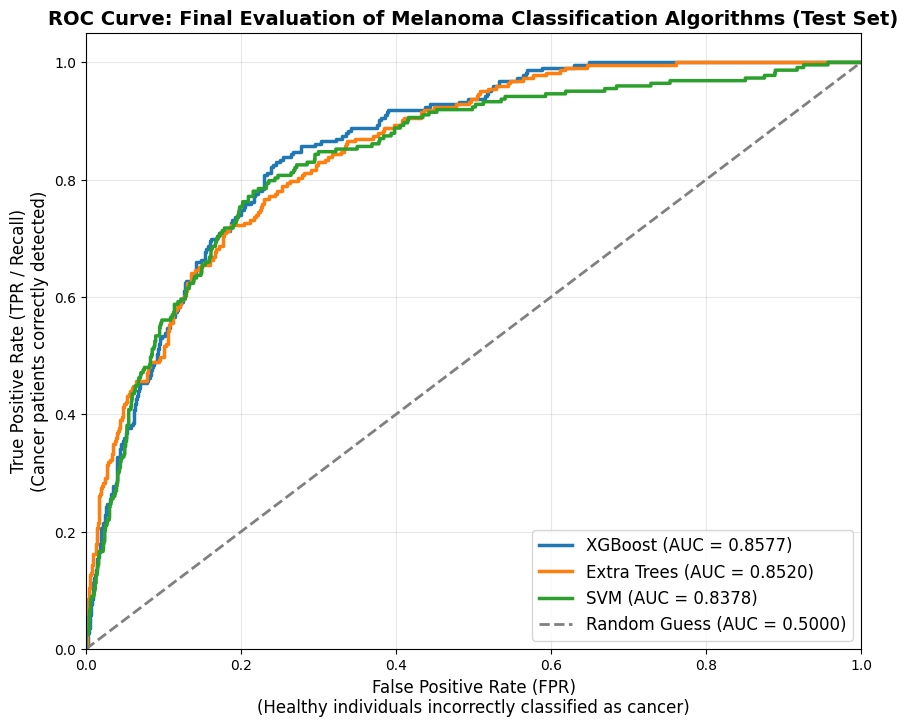

DONE! High-resolution ROC Curve saved at:
 /content/drive/MyDrive/ComVis/GitHub/Dynamic_TH/Hasil_Evaluasi/ROC_Curve_Final_TestSet.png


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import os

print("Creating ROC Curve plot and saving to Drive...")

plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

path_simpan_gambar = '/content/drive/MyDrive/ComVis/GitHub/Dynamic_TH/Hasil_Evaluasi/'
os.makedirs(path_simpan_gambar, exist_ok=True)

for (name, model), color in zip(models.items(), colors):
    prob_test_roc = model.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, prob_test_roc)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2.5,
             label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)\n(Healthy individuals incorrectly classified as cancer)', fontsize=12)
plt.ylabel('True Positive Rate (TPR / Recall)\n(Cancer patients correctly detected)', fontsize=12)
plt.title('ROC Curve: Final Evaluation of Melanoma Classification Algorithms (Test Set)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)

path_gambar = os.path.join(path_simpan_gambar, 'ROC_Curve_Final_TestSet.png')
plt.savefig(path_gambar, dpi=300, bbox_inches='tight')
plt.show()

print(f"DONE! High-resolution ROC Curve saved at:\n {path_gambar}")


# Feature Importance

In [13]:
print("=========================================")
print("MAPPING FITUR WARNA (HSV) - 15 Fitur")
print("=========================================")
channels = ['Hue (H)', 'Saturation (S)', 'Value (V)']

metrics_hsv = ['Mean', 'Standard Deviation', 'Skewness', 'Kurtosis', 'Range']

idx = 0
for channel in channels:
    for metric in metrics_hsv:
        print(f"hsv_{idx} = {metric} of {channel} channel")
        idx += 1

print("\n=========================================")
print("MAPPING FITUR TEKSTUR (GLCM) - 20 Fitur")
print("=========================================")

metrics_glcm = ['Contrast', 'Energy', 'Correlation', 'Homogeneity', 'Entropy']
angles = ['0°', '45°', '90°', '135°']

idx = 0
for metric in metrics_glcm:
    for angle in angles:
        print(f"glcm_{idx} = {metric} at {angle} angle")
        idx += 1

MAPPING FITUR WARNA (HSV) - 15 Fitur
hsv_0 = Mean of Hue (H) channel
hsv_1 = Standard Deviation of Hue (H) channel
hsv_2 = Skewness of Hue (H) channel
hsv_3 = Kurtosis of Hue (H) channel
hsv_4 = Range of Hue (H) channel
hsv_5 = Mean of Saturation (S) channel
hsv_6 = Standard Deviation of Saturation (S) channel
hsv_7 = Skewness of Saturation (S) channel
hsv_8 = Kurtosis of Saturation (S) channel
hsv_9 = Range of Saturation (S) channel
hsv_10 = Mean of Value (V) channel
hsv_11 = Standard Deviation of Value (V) channel
hsv_12 = Skewness of Value (V) channel
hsv_13 = Kurtosis of Value (V) channel
hsv_14 = Range of Value (V) channel

MAPPING FITUR TEKSTUR (GLCM) - 20 Fitur
glcm_0 = Contrast at 0° angle
glcm_1 = Contrast at 45° angle
glcm_2 = Contrast at 90° angle
glcm_3 = Contrast at 135° angle
glcm_4 = Energy at 0° angle
glcm_5 = Energy at 45° angle
glcm_6 = Energy at 90° angle
glcm_7 = Energy at 135° angle
glcm_8 = Correlation at 0° angle
glcm_9 = Correlation at 45° angle
glcm_10 = Correl

Extracting Feature Importance from Ensemble Models...


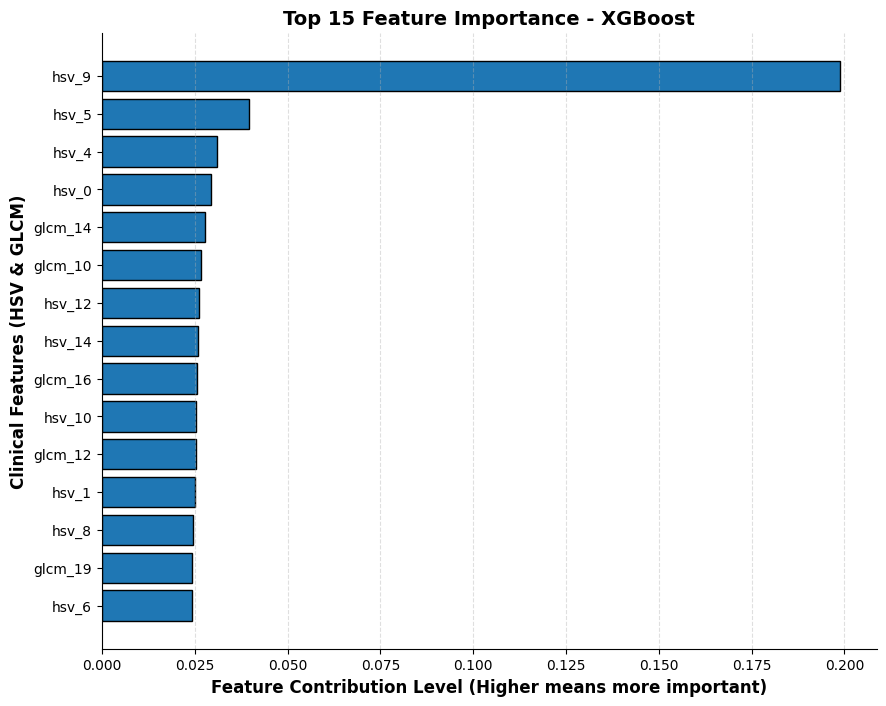

Feature Importance chart for XGBoost saved at:
 /content/drive/MyDrive/ComVis/GitHub/Dynamic_TH/Hasil_Evaluasi/Feature_Importance_XGBoost.png



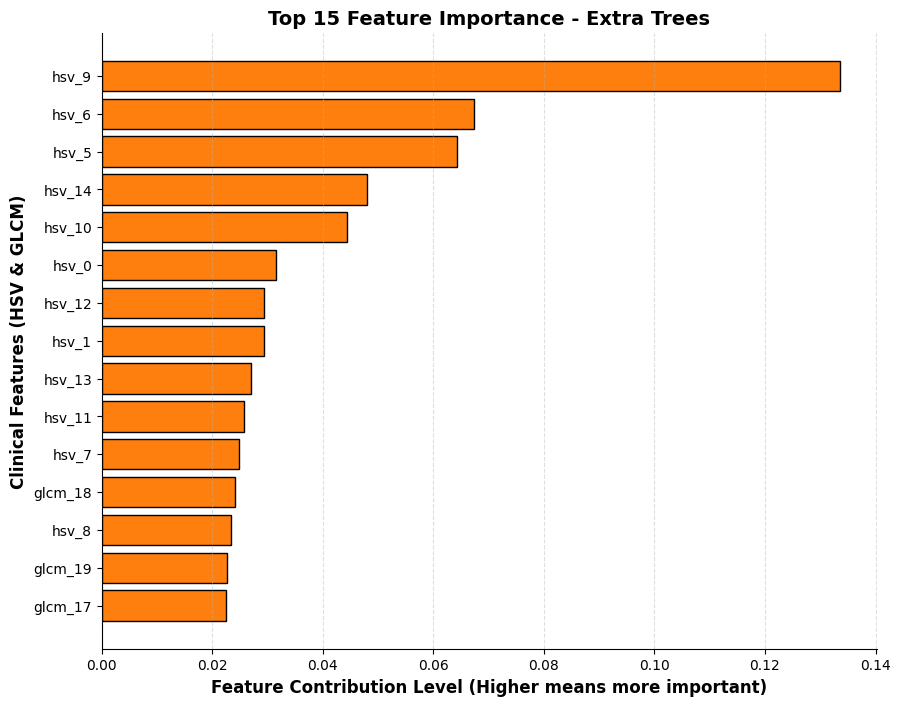

Feature Importance chart for Extra Trees saved at:
 /content/drive/MyDrive/ComVis/GitHub/Dynamic_TH/Hasil_Evaluasi/Feature_Importance_Extra_Trees.png

Note: SVM (RBF Kernel) is skipped because it maps data into infinite dimensions, so it does not have built-in linear weight scores.


In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import os

print("Extracting Feature Importance from Ensemble Models...")

path_simpan_gambar = '/content/drive/MyDrive/ComVis/GitHub/Dynamic_TH/Hasil_Evaluasi/'
os.makedirs(path_simpan_gambar, exist_ok=True)

tree_models = ['XGBoost', 'Extra Trees']
warna_grafik = {'XGBoost': '#1f77b4', 'Extra Trees': '#ff7f0e'}

for name in tree_models:
    model = models[name]

    importances = model.feature_importances_

    df_imp = pd.DataFrame({
        'Feature': fitur_cols,
        'Importance Score': importances
    })

    df_top15 = df_imp.sort_values(by='Importance Score', ascending=True).tail(15)

    plt.figure(figsize=(10, 8))
    plt.barh(df_top15['Feature'], df_top15['Importance Score'], color=warna_grafik[name], edgecolor='black')

    plt.title(f'Top 15 Feature Importance - {name}', fontsize=14, fontweight='bold')
    plt.xlabel('Feature Contribution Level (Higher means more important)', fontsize=12, fontweight='bold')
    plt.ylabel('Clinical Features (HSV & GLCM)', fontsize=12, fontweight='bold')
    plt.grid(axis='x', alpha=0.4, linestyle='--')

    plt.gca().spines[['top', 'right']].set_visible(False)

    path_gambar = os.path.join(path_simpan_gambar, f'Feature_Importance_{name.replace(" ", "_")}.png')
    plt.savefig(path_gambar, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Feature Importance chart for {name} saved at:\n {path_gambar}\n")

print("Note: SVM (RBF Kernel) is skipped because it maps data into infinite dimensions, so it does not have built-in linear weight scores.")

# Confusion Matrix and Specify

Calculating Confusion Matrix and Specificity...

 CONFUSION MATRIX REPORT: XGBOOST (Thresh: 0.25)
 True Negatives (TN) : 1259
 False Positives (FP): 522
 False Negatives (FN): 32
 True Positives (TP) : 191
-----------------------------------------
 SENSITIVITY (Recall) : 85.65%
 SPECIFICITY          : 70.69%



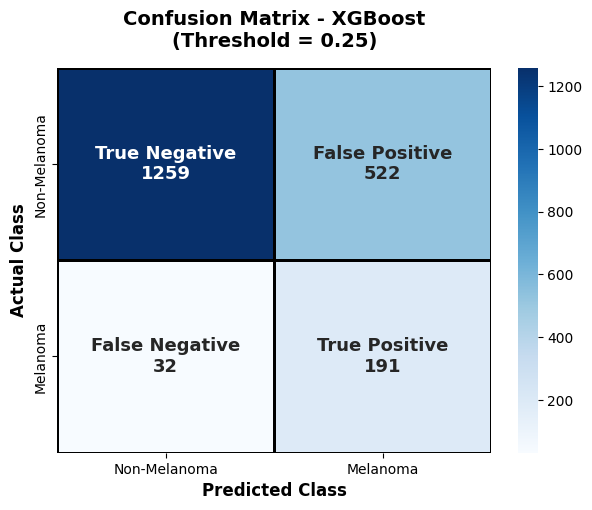


 CONFUSION MATRIX REPORT: EXTRA TREES (Thresh: 0.25)
 True Negatives (TN) : 1158
 False Positives (FP): 623
 False Negatives (FN): 29
 True Positives (TP) : 194
-----------------------------------------
 SENSITIVITY (Recall) : 87.00%
 SPECIFICITY          : 65.02%



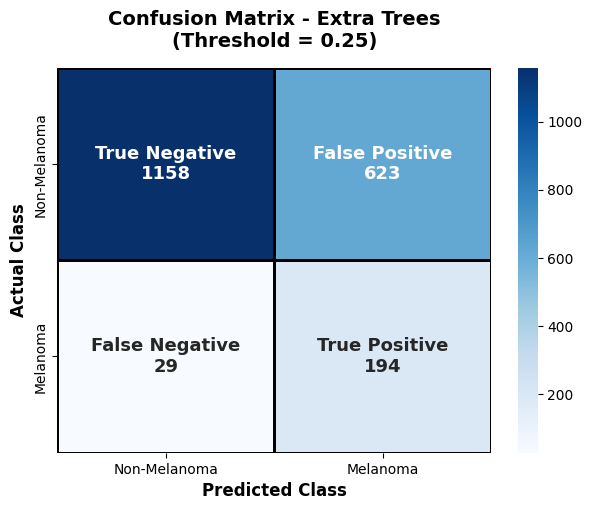


 CONFUSION MATRIX REPORT: SVM (Thresh: 0.25)
 True Negatives (TN) : 1423
 False Positives (FP): 358
 False Negatives (FN): 55
 True Positives (TP) : 168
-----------------------------------------
 SENSITIVITY (Recall) : 75.34%
 SPECIFICITY          : 79.90%



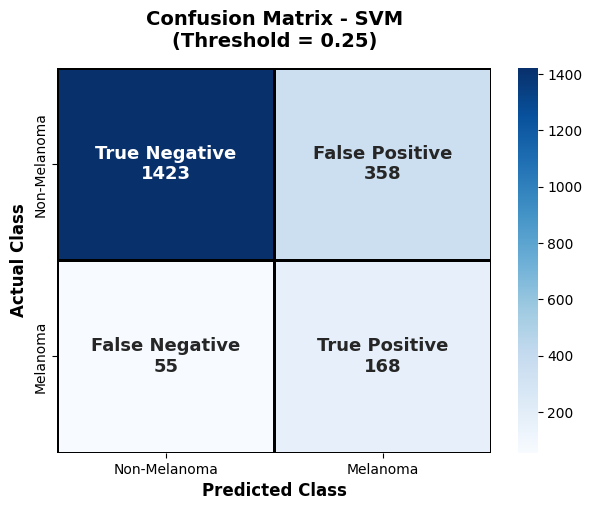

 Confusion Matrix visualizations (Dynamic Thresholds) saved in Google Drive!


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import os

print("Calculating Confusion Matrix and Specificity...")

path_simpan_gambar = '/content/drive/MyDrive/ComVis/GitHub/Dynamic_TH/Hasil_Evaluasi/'
os.makedirs(path_simpan_gambar, exist_ok=True)

optimal_thresholds = {
    'XGBoost': 0.25,
    'Extra Trees': 0.25,
    'SVM': 0.25
}

for name, model in models.items():
    current_thresh = optimal_thresholds[name]

    prob_test = model.predict_proba(X_test_scaled)[:, 1]
    y_test_pred = np.where(prob_test >= current_thresh, 1, 0)

    cm = confusion_matrix(y_test, y_test_pred)
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    print(f"\n=========================================")
    print(f" CONFUSION MATRIX REPORT: {name.upper()} (Thresh: {current_thresh})")
    print(f"=========================================")
    print(f" True Negatives (TN) : {tn}")
    print(f" False Positives (FP): {fp}")
    print(f" False Negatives (FN): {fn}")
    print(f" True Positives (TP) : {tp}")
    print(f"-----------------------------------------")
    print(f" SENSITIVITY (Recall) : {recall*100:.2f}%")
    print(f" SPECIFICITY          : {specificity*100:.2f}%")
    print(f"=========================================\n")

    plt.figure(figsize=(7, 5))

    group_names = ['True Negative', 'False Positive', 'False Negative', 'True Positive']
    group_counts = [f"{value}" for value in cm.flatten()]
    labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
    labels = np.asarray(labels).reshape(2,2)

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
                xticklabels=['Non-Melanoma', 'Melanoma'],
                yticklabels=['Non-Melanoma', 'Melanoma'],
                annot_kws={"size": 13, "weight": "bold"},
                linewidths=1, linecolor='black')

    plt.title(f'Confusion Matrix - {name}\n(Threshold = {current_thresh})', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Actual Class', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')

    path_gambar = os.path.join(path_simpan_gambar, f'Confusion_Matrix_{name.replace(" ", "_")}.png')
    plt.savefig(path_gambar, dpi=300, bbox_inches='tight')
    plt.show()

print(" Confusion Matrix visualizations (Dynamic Thresholds) saved in Google Drive!")